# Linear Classification


In [92]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

### Divide the dataset into training and testing

In [93]:
df = pd.read_csv("BankNote_Authentication.csv")
df.head()


X = df.iloc[:, :-1]  
Y = df.iloc[:, -1] 

print(X.head())
print("-------------------------------------")
print(Y.head())

xTrain, xTest, yTrain, yTest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# not scaled data
xTrainNoStd=xTrain
xTestNoStd=xTest

# scaled data
scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest  = scaler.transform(xTest)

print("Train :", xTrain.shape, yTrain.shape)
print("Test :", xTest.shape, yTest.shape)

# one hot encoding
enc = OneHotEncoder(sparse_output=False)
yTrainOHE = enc.fit_transform(yTrain.values.reshape(-1, 1))
yTestOHE  = enc.transform(yTest.values.reshape(-1, 1))

print("yTrainOHE :", yTrainOHE.shape)
print("yTestOHE :", yTestOHE.shape)


   variance  skewness  curtosis  entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880
-------------------------------------
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64
Train : (1097, 4) (1097,)
Test : (275, 4) (275,)
yTrainOHE : (1097, 2)
yTestOHE : (275, 2)


###  classification model with and without l2 regularization

In [94]:
# L(w)=(XW-Y)^T (XW-Y)
# => Wopt=(X^T X)^(-1) X^T Y

def biadAdd(X):
    ''' Adds a ones column to X (for the bias)'''
    return np.hstack([np.ones((X.shape[0], 1)), X])

def predict(X, W):
    ''' Return class predictions given optimal weight W. '''
    scores = X @ W         
    return np.argmax(scores, axis=1)  


xTrain = biadAdd(xTrain)
xTest  = biadAdd(xTest)

# w-optimal
XtX = xTrain.T @ xTrain
Xty = xTrain.T @ yTrainOHE
wOpt = np.linalg.pinv(XtX) @ Xty  

# Predictions
yTrainPred = predict(xTrain, wOpt)
yTestPred  = predict(xTest, wOpt)

trainAcc = accuracy_score(yTrain, yTrainPred)
testAcc  = accuracy_score(yTest, yTestPred)


print(f"Linear Classification Train Acc: {trainAcc:.4f} | Test Acc: {testAcc:.4f}")

# L(w)=(XW-Y)^T (XW-Y) + ||(λ)||^2
# => Wopt=((X^T X)+λI)^(-1) X^T Y

def ridgeReg(X, Y, lam=1.0):
    dplus1 = X.shape[1]
    I = np.eye(dplus1)
    I[0, 0] = 0.0  # don't regularize bias
    XtX = X.T @ X
    Xty = X.T @ Y
    wOpt = np.linalg.pinv(XtX + lam * I) @ Xty
    return wOpt

wOptRidge = ridgeReg(xTrain, yTrainOHE, lam=100)

# Predictions
yTrainPredRidge = predict(xTrain, wOptRidge)
yTestPredRidge  = predict(xTest, wOptRidge)

trainAccRidge = accuracy_score(yTrain, yTrainPredRidge)
testAccRidge  = accuracy_score(yTest, yTestPredRidge)


print(f"Linear Classification with l2 regularization Train Acc: {trainAccRidge:.4f} | Test Acc: {testAccRidge:.4f}")

Linear Classification Train Acc: 0.9790 | Test Acc: 0.9673
Linear Classification with l2 regularization Train Acc: 0.9790 | Test Acc: 0.9709


### Plot of test accuracy and training accuracy with various λ values and observations

λ values at intervals:
λ=  0.0010 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0012 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0014 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0016 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0019 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0022 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0026 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0031 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0036 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0043 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0050 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0059 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0069 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0081 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0096 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0112 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0132 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0155 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0182 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0214 | Train Acc=0.9790 | Test Acc=0.9673
λ=  0.0251 | Trai

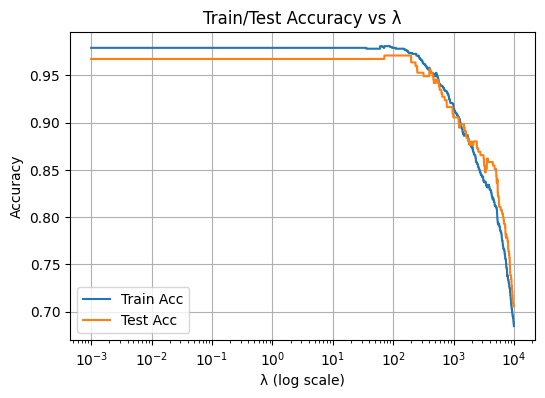

In [95]:
lambdaRange = np.logspace(-3, 4, 10000)  # from 0.001 to 10000
results = []

for lamVal in lambdaRange:
    wVal = ridgeReg(xTrain, yTrainOHE, lam=lamVal)
    
    yTrainPred = predict(xTrain, wVal)
    yTestPred  = predict(xTest, wVal)
    
    trainAcc = accuracy_score(yTrain, yTrainPred)
    testAcc  = accuracy_score(yTest, yTestPred)
    
    results.append((lamVal, trainAcc, testAcc))

# Print every 100th iteration (since we have 10000 points)
print("λ values at intervals:")
for i in range(0, len(results), 100):
    lamVal, trainAcc, testAcc = results[i]
    print(f"λ={lamVal:8.4f} | Train Acc={trainAcc:.4f} | Test Acc={testAcc:.4f}")

# Best λ based on test accuracy
bestLam, bestTrain, bestTest = max(results, key=lambda t: t[2])
print(f"\nBest λ={bestLam:.4f} | Train Acc={bestTrain:.4f} | Test Acc={bestTest:.4f}")

# Plot Train and Test Accuracy
plt.figure(figsize=(6,4))
plt.semilogx([r[0] for r in results], [r[1] for r in results], label="Train Acc")
plt.semilogx([r[0] for r in results], [r[2] for r in results], label="Test Acc")
plt.xlabel("λ (log scale)")
plt.ylabel("Accuracy")
plt.title("Train/Test Accuracy vs λ")
plt.legend()
plt.grid(True)
plt.show()


## Observation
<li>Ridge regression exhibits the expected bias–variance tradeoff.
<li> For very small λ, the model is nearly identical to ordinary least squares, achieving high but potentially overfit accuracy.
<li> With moderate λ (~70), the model achieves the best generalization performance with a slight gain in test accuracy. <li> For large λ values, both training and test performance degrade due to underfitting as the weights are overly penalized.

### 3D plot of data by choosing important 3 features.

Top 3 features: ['skewness' 'curtosis' 'variance']


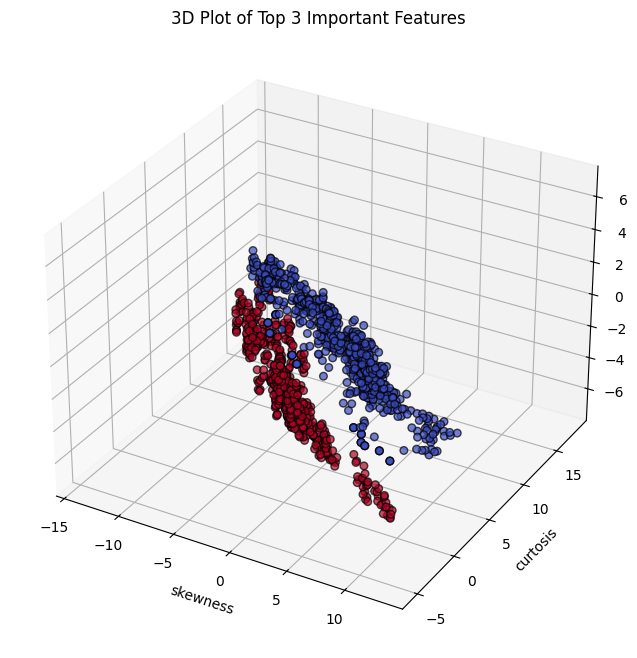

In [99]:
featImp = np.linalg.norm(wOpt[1:, :], axis=1) # l2 norm

featName = np.array(df.columns[:-1])

# Rank features
sortedIdx = np.argsort(featImp)[::-1]
top3Idx = sortedIdx[:3]
top3Feat = featName[top3Idx]

print("Top 3 features:", top3Feat)

xArr = X.to_numpy()
yArr = Y.to_numpy()

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xArr[:, top3Idx[0]],
    xArr[:, top3Idx[1]],
    xArr[:, top3Idx[2]],
    c=yArr, cmap="coolwarm", s=30, alpha=0.7, edgecolor="k"
)

ax.set_xlabel(top3Feat[0])
ax.set_ylabel(top3Feat[1])
ax.set_zlabel(top3Feat[2])
plt.title("3D Plot of Top 3 Important Features")
plt.show()


### Intentionally shift few data points and create outliers

In [100]:
xOutlier = X.copy().to_numpy()
yOutlier = Y.copy().to_numpy()

np.random.seed(42)
nOutliers = 40
indices = np.random.choice(len(xOutlier), nOutliers, replace=False)

# Shift chosen points in random direction
xOutlier[indices] += np.random.normal(20, 5, xOutlier[indices].shape)

print(f"Added {nOutliers} outliers.")

Added 40 outliers.


### Linear classifier on the dataset with outliers and  impact of outliers on model’s performance

In [122]:
# Split with outliers
xTrainO, xTestO, yTrainO, yTestO = train_test_split(
    xOutlier, yOutlier, test_size=0.2, random_state=42, stratify=yOutlier
)

# Standardize
scaler2 = StandardScaler()
xTrainO = scaler2.fit_transform(xTrainO)
xTestO  = scaler2.transform(xTestO)

# Add bias
xTrainO = biadAdd(xTrainO)
xTestO  = biadAdd(xTestO)

# One-hot encode labels
enc2 = OneHotEncoder(sparse_output=False)
yTrainOOHE = enc2.fit_transform(yTrainO.reshape(-1, 1))
yTestOOHE  = enc2.transform(yTestO.reshape(-1, 1))

# Without Regularization
xTx = xTrainO.T @ xTrainO
xTy = xTrainO.T @ yTrainOOHE
wOptOut = np.linalg.pinv(xTx) @ xTy  

# Predictions
trainPredOut = predict(xTrainO, wOptOut)
testPredOut  = predict(xTestO, wOptOut)

trainAccOut = accuracy_score(yTrainO, trainPredOut)
testAccOut  = accuracy_score(yTestO, testPredOut)

print(f"Linear Classification (with Outliers) Train Acc: {trainAccOut:.4f} | Test Acc: {testAccOut:.4f}")

# With L2 Regularization
wOptRidgeOut = ridgeReg(xTrainO, yTrainOOHE, lam=241)  

# Predictions
trainPredRidgeOut = predict(xTrainO, wOptRidgeOut)
testPredRidgeOut  = predict(xTestO, wOptRidgeOut)

trainAccOutRidge = accuracy_score(yTrainO, trainPredRidgeOut)
testAccOutRidge  = accuracy_score(yTestO, testPredRidgeOut)

print(f"Linear Classification with L2 Regularization (with Outliers) Train Acc: {trainAccOutRidge:.4f} | Test Acc: {testAccOutRidge:.4f}")


Linear Classification (with Outliers) Train Acc: 0.8797 | Test Acc: 0.8545
Linear Classification with L2 Regularization (with Outliers) Train Acc: 0.8505 | Test Acc: 0.8582


##  Impact of outliers on model's performance
<li> Outliers negatively impact model performance by reducing both train and test accuracy (from ~97% to ~85%). They distort the decision boundary
<li> L2 regularization makes the model slightly more robust by preventing extreme weight values, improving test accuracy marginally.However, it cannot completely eliminate the harmful effect of outliers.